In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Reduce N for computational feasibility
N = 10**4 # Using N=10^4 as mentioned for intensive calculations
t_min, t_max = 1000, 10000
n_peaks = 50

print(f"Analysis parameters:")
print(f" N = {N} (reduced for computational feasibility)")
print(f" t range = [{t_min}, {t_max}]")
print(f" Peaks per function = {n_peaks}")


Analysis parameters:
 N = 10000 (reduced for computational feasibility)
 t range = [1000, 10000]
 Peaks per function = 50


In [2]:

# Define helper functions
def is_squarefree(n):
 if n <= 1:
 return n == 1
 i = 2
 while i * i <= n:
 if n % (i * i) == 0:
 return False
 i += 1
 return True

def omega(n):
 if n <= 1:
 return 0
 count = 0
 d = 2
 temp_n = n
 while d * d <= temp_n:
 if temp_n % d == 0:
 count += 1
 while temp_n % d == 0:
 temp_n //= d
 d += 1
 if temp_n > 1:
 count += 1
 return count

def big_omega(n):
 if n <= 1:
 return 0
 count = 0
 d = 2
 temp_n = n
 while d * d <= temp_n:
 while temp_n % d == 0:
 count += 1
 temp_n //= d
 d += 1
 if temp_n > 1:
 count += 1
 return count

def mobius(n):
 if n == 1:
 return 1
 if not is_squarefree(n):
 return 0
 return (-1) ** omega(n)

def liouville(n):
 return (-1) ** big_omega(n)

def chi4_mod5(n):
 n_mod = n % 5
 if n_mod == 1 or n_mod == 4:
 return 1
 elif n_mod == 2 or n_mod == 3:
 return -1
 else:
 return 0

print("Helper functions defined.")


Helper functions defined.


In [3]:

# Generate coefficients for all seven functions
print("Generating coefficients...")

coeffs = {}

# 1. Standard: Riemann ζ
coeffs['zeta'] = np.ones(N + 1)
coeffs['zeta'][0] = 0

# 2. Standard: L(s, χ₄)
coeffs['L_chi4'] = np.array([chi4_mod5(n) for n in range(N + 1)])

# 3. Anomalous Multiplicative: λ(n)
coeffs['L_liouville'] = np.array([liouville(n) if n > 0 else 0 for n in range(N + 1)])

# 4. Anomalous Multiplicative: μ(n)
coeffs['L_mobius'] = np.array([mobius(n) if n > 0 else 0 for n in range(N + 1)])

# 5. Anomalous Multiplicative: f_rand (seed=42)
np.random.seed(42)
f_rand = np.random.choice([-1, 1], size=N + 1)
f_rand[0] = 0
coeffs['f_rand'] = f_rand

# 6. Anomalous Non-Multiplicative: L_DH (periodic pattern)
L_DH_coeffs = np.zeros(N + 1)
for n in range(1, N + 1):
 n_mod4 = n % 4
 if n_mod4 == 1:
 L_DH_coeffs[n] = 2
 elif n_mod4 == 3:
 L_DH_coeffs[n] = -2
coeffs['L_DH'] = L_DH_coeffs

# 7. Control Non-Multiplicative: f_fully_rand (seed=42)
np.random.seed(42)
f_fully_rand = np.zeros(N + 1)
for n in range(1, N + 1):
 if is_squarefree(n):
 f_fully_rand[n] = np.random.choice([-1, 1])
coeffs['f_fully_rand'] = f_fully_rand

for name in coeffs:
 print(f" {name:15s}: {np.sum(coeffs[name] != 0):5d} non-zero coeffs")


Generating coefficients...
 zeta : 10000 non-zero coeffs
 L_chi4 : 8000 non-zero coeffs
 L_liouville : 10000 non-zero coeffs
 L_mobius : 6083 non-zero coeffs
 f_rand : 10000 non-zero coeffs
 L_DH : 5000 non-zero coeffs
 f_fully_rand : 6083 non-zero coeffs


In [4]:

# Compute partial sums D(t; N) using batch processing
# Use a coarse t grid to identify peaks

delta_t = 2.0 # Coarse grid
t_grid = np.arange(t_min, t_max, delta_t)
print(f"Computing D(t; N) on {len(t_grid)} t-values (Δt = {delta_t})")

# Pre-compute
n_values = np.arange(1, N + 1)
sqrt_n = np.sqrt(n_values)
log_n = np.log(n_values)

D_values = {}

# Process in batches to avoid memory issues
batch_size = 500

for func_name, coeff in coeffs.items():
 print(f" {func_name}...", end=" ", flush=True)
 
 a_n_over_sqrt_n = coeff[1:] / sqrt_n
 D_t = np.zeros(len(t_grid), dtype=complex)
 
 # Process t values in batches
 for i in range(0, len(t_grid), batch_size):
 t_batch = t_grid[i:i+batch_size]
 # Compute outer product for this batch
 t_log_n = np.outer(t_batch, log_n)
 phases = np.exp(-1j * t_log_n)
 D_t[i:i+batch_size] = np.sum(a_n_over_sqrt_n * phases, axis=1)
 
 D_values[func_name] = D_t
 print(f"max |D| = {np.max(np.abs(D_t)):.3f}")

print("Partial sums computed.")


Computing D(t; N) on 4500 t-values (Δt = 2.0)
 zeta... 

max |D| = 15.690
 L_chi4... 

max |D| = 16.862
 L_liouville... 

max |D| = 27.669
 L_mobius... 

max |D| = 14.282
 f_rand... 

max |D| = 9.786
 L_DH... 

max |D| = 21.797
 f_fully_rand... 

max |D| = 8.556
Partial sums computed.


In [5]:

# Step 3: Identify 50 peaks with highest |D(t; N)| for each function

peak_data = {}

for func_name, D_t in D_values.items():
 magnitudes = np.abs(D_t)
 
 # Find indices of top 50 peaks
 top_indices = np.argsort(magnitudes)[-n_peaks:][::-1]
 
 peak_data[func_name] = {
 'indices': top_indices,
 't_values': t_grid[top_indices],
 'magnitudes': magnitudes[top_indices],
 'D_complex': D_t[top_indices]
 }
 
 print(f"{func_name:15s}: Top 5 peaks at t = {peak_data[func_name]['t_values'][:5]}")
 print(f" Magnitudes: {peak_data[func_name]['magnitudes'][:5]}")

print(f"\nTotal peaks identified: {len(peak_data)} × {n_peaks} = {len(peak_data) * n_peaks}")


zeta : Top 5 peaks at t = [9654. 9826. 7578. 6726. 8476.]
 Magnitudes: [15.68968213 15.6606707 15.40948913 15.18285224 15.14834717]
L_chi4 : Top 5 peaks at t = [8788. 7764. 6912. 6540. 3286.]
 Magnitudes: [16.86218169 16.58917263 16.19520135 16.03754605 15.70640925]
L_liouville : Top 5 peaks at t = [2434. 5362. 2742. 4464. 6740.]
 Magnitudes: [27.66918294 25.92541926 24.50390479 24.09935924 22.88056851]
L_mobius : Top 5 peaks at t = [1610. 2434. 5978. 7700. 8200.]
 Magnitudes: [14.2822217 13.48105717 12.747537 12.43863165 12.20390626]
f_rand : Top 5 peaks at t = [6586. 7328. 3256. 2558. 6062.]
 Magnitudes: [9.78622442 8.85326421 8.57167412 8.34094196 7.90291152]
L_DH : Top 5 peaks at t = [7312. 7964. 5688. 6992. 9514.]
 Magnitudes: [21.79726537 21.69321816 20.76179848 19.82553712 18.4253134 ]
f_fully_rand : Top 5 peaks at t = [1882. 7630. 1808. 4138. 5524.]
 Magnitudes: [8.55552269 7.23893454 6.90981063 6.77700096 6.57154885]

Total peaks identified: 7 × 50 = 350


In [6]:

# Step 4: Compute the three metrics for each peak
# Metrics: M_coh, R_comp, and Sum of Squared ACF

# For each peak at t_0, we need a local window around it
# M_coh and R_comp require analyzing the time series around the peak

# Define window parameters
window_half_width = 50 # Points around peak
lag_max = 50 # For ACF computation

print(f"Computing metrics for each peak...")
print(f" Window half-width: ±{window_half_width} points")
print(f" ACF lags: 1 to {lag_max}")


Computing metrics for each peak...
 Window half-width: ±50 points
 ACF lags: 1 to 50


In [7]:

# Compute metrics
# M_coh: Coherence magnitude (related to correlation between Re and Im parts)
# R_comp: Resonance compression (ratio of peak to local variance)
# Sum of Squared ACF: Autocorrelation of coefficients

def compute_acf_sum_squared(coeffs, lag_max=50):
 """Compute sum of squared ACF values for lags 1 to lag_max"""
 # Use only non-zero coefficients for meaningful ACF
 a_n = coeffs[1:] # Exclude a_0
 
 # Compute ACF manually
 n = len(a_n)
 mean_a = np.mean(a_n)
 var_a = np.var(a_n)
 
 if var_a < 1e-10:
 return 0.0
 
 acf_squared_sum = 0.0
 for lag in range(1, min(lag_max + 1, n)):
 # ACF at lag k
 numerator = np.sum((a_n[:-lag] - mean_a) * (a_n[lag:] - mean_a)) / n
 acf = numerator / var_a
 acf_squared_sum += acf ** 2
 
 return acf_squared_sum

def compute_coherence_magnitude(D_window):
 """Compute M_coh: magnitude of coherence between Re(D) and Im(D)"""
 real_part = np.real(D_window)
 imag_part = np.imag(D_window)
 
 # Coherence via correlation
 if len(real_part) < 2:
 return 0.0
 
 corr = np.corrcoef(real_part, imag_part)[0, 1]
 return np.abs(corr)

def compute_resonance_compression(D_t, peak_idx, window_half_width):
 """Compute R_comp: ratio of peak magnitude to local RMS"""
 start_idx = max(0, peak_idx - window_half_width)
 end_idx = min(len(D_t), peak_idx + window_half_width + 1)
 
 window = D_t[start_idx:end_idx]
 magnitudes = np.abs(window)
 
 peak_magnitude = magnitudes[peak_idx - start_idx]
 rms = np.sqrt(np.mean(magnitudes ** 2))
 
 if rms < 1e-10:
 return 0.0
 
 return peak_magnitude / rms

# First, compute ACF sum squared for each function's coefficients (same for all peaks)
acf_sums = {}
print("\nComputing Sum of Squared ACF for coefficient sequences:")
for func_name, coeff in coeffs.items():
 acf_sum = compute_acf_sum_squared(coeff, lag_max=lag_max)
 acf_sums[func_name] = acf_sum
 print(f" {func_name:15s}: ACF sum squared = {acf_sum:.6f}")



Computing Sum of Squared ACF for coefficient sequences:
 zeta : ACF sum squared = 0.000000
 L_chi4 : ACF sum squared = 12.432618
 L_liouville : ACF sum squared = 0.003226
 L_mobius : ACF sum squared = 0.003225
 f_rand : ACF sum squared = 0.004307
 L_DH : ACF sum squared = 24.870221
 f_fully_rand : ACF sum squared = 0.003911


In [8]:

# Now compute M_coh and R_comp for each peak
print("\nComputing M_coh and R_comp for each peak...")

metrics_list = []

for func_name in coeffs.keys():
 print(f" Processing {func_name}...", end=" ", flush=True)
 
 D_t = D_values[func_name]
 peak_indices = peak_data[func_name]['indices']
 
 for i, peak_idx in enumerate(peak_indices):
 # Compute window for M_coh
 start_idx = max(0, peak_idx - window_half_width)
 end_idx = min(len(D_t), peak_idx + window_half_width + 1)
 D_window = D_t[start_idx:end_idx]
 
 # Compute metrics
 M_coh = compute_coherence_magnitude(D_window)
 R_comp = compute_resonance_compression(D_t, peak_idx, window_half_width)
 ACF_sum = acf_sums[func_name]
 
 # Determine class
 if func_name in ['zeta', 'L_chi4']:
 class_label = 'Standard'
 else:
 class_label = 'Anomalous'
 
 metrics_list.append({
 'function': func_name,
 'peak_idx': i,
 't_value': t_grid[peak_idx],
 'magnitude': np.abs(D_t[peak_idx]),
 'M_coh': M_coh,
 'R_comp': R_comp,
 'ACF_sum_squared': ACF_sum,
 'class': class_label
 })
 
 print(f"{n_peaks} peaks")

# Create DataFrame
df_metrics = pd.DataFrame(metrics_list)

print(f"\nTotal data points: {len(df_metrics)}")
print(f"Standard class: {len(df_metrics[df_metrics['class'] == 'Standard'])}")
print(f"Anomalous class: {len(df_metrics[df_metrics['class'] == 'Anomalous'])}")
print("\nFirst few rows:")
print(df_metrics.head(10))



Computing M_coh and R_comp for each peak...
 Processing zeta... 

50 peaks
 Processing L_chi4... 

50 peaks
 Processing L_liouville... 

50 peaks
 Processing L_mobius... 

50 peaks
 Processing f_rand... 

50 peaks
 Processing L_DH... 

50 peaks
 Processing f_fully_rand... 

50 peaks

Total data points: 350
Standard class: 100
Anomalous class: 250

First few rows:
 function peak_idx t_value magnitude M_coh R_comp ACF_sum_squared \
0 zeta 0 9654.0 15.689682 0.142430 6.026804 0.0 
1 zeta 1 9826.0 15.660671 0.075950 5.681782 0.0 
2 zeta 2 7578.0 15.409489 0.166154 6.055256 0.0 
3 zeta 3 6726.0 15.182852 0.430099 5.137706 0.0 
4 zeta 4 8476.0 15.148347 0.391899 5.085591 0.0 
5 zeta 5 4478.0 14.549092 0.176437 5.445861 0.0 
6 zeta 6 8956.0 14.431574 0.041120 5.127148 0.0 
7 zeta 7 9128.0 14.302390 0.184265 4.570922 0.0 
8 zeta 8 9174.0 14.028707 0.144372 4.263205 0.0 
9 zeta 9 8104.0 13.817864 0.082067 4.347036 0.0 

 class 
0 Standard 
1 Standard 
2 Standard 
3 Standard 
4 Standard 
5 Standard 
6 Standard 
7 Standard 
8 Standard 
9 Standard 


In [9]:

# Check summary statistics by class
print("Summary statistics by class:\n")
print(df_metrics.groupby('class')[['M_coh', 'R_comp', 'ACF_sum_squared']].describe())

print("\n\nMean values by class:")
print(df_metrics.groupby('class')[['M_coh', 'R_comp', 'ACF_sum_squared']].mean())

print("\n\nMean values by function:")
print(df_metrics.groupby('function')[['M_coh', 'R_comp', 'ACF_sum_squared']].mean())


Summary statistics by class:

 M_coh \
 count mean std min 25% 50% 75% 
class 
Anomalous 250.0 0.129166 0.106052 0.000026 0.048934 0.099652 0.177786 
Standard 100.0 0.146859 0.122994 0.004164 0.052577 0.129338 0.186598 

 R_comp ... ACF_sum_squared \
 max count mean ... 75% max count 
class ... 
Anomalous 0.484450 250.0 3.343577 ... 3.998443 7.134021 250.0 
Standard 0.760074 100.0 4.299567 ... 4.752141 6.055256 100.0 

 \
 mean std min 25% 50% 75% 
class 
Anomalous 4.976978 9.966575 0.003225 0.003226 0.003911 0.004307 
Standard 6.216309 6.247626 0.000000 0.000000 6.216309 12.432618 

 
 max 
class 
Anomalous 24.870221 
Standard 12.432618 

[2 rows x 24 columns]


Mean values by class:
 M_coh R_comp ACF_sum_squared
class 
Anomalous 0.129166 3.343577 4.976978
Standard 0.146859 4.299567 6.216309


Mean values by function:
 M_coh R_comp ACF_sum_squared
function 
L_DH 0.112658 3.402668 24.870221
L_chi4 0.155232 4.293215 12.432618
L_liouville 0.182334 4.968953 0.003226
L_mobius 0.147484 3.73

In [10]:

# Step 5: Train SVM classifier with Leave-One-Out Cross-Validation

# Prepare feature matrix and labels
X = df_metrics[['M_coh', 'R_comp', 'ACF_sum_squared']].values
y = (df_metrics['class'] == 'Anomalous').astype(int).values # 1 for Anomalous, 0 for Standard

print(f"Feature matrix shape: {X.shape}")
print(f"Class distribution: Standard={np.sum(y==0)}, Anomalous={np.sum(y==1)}")

# Normalize features by standard deviation as recommended
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeature scaling statistics:")
print(f" Means: {scaler.mean_}")
print(f" Std devs: {scaler.scale_}")

# Train SVM with linear kernel and LOO cross-validation
svm = SVC(kernel='linear', random_state=42)
loo = LeaveOneOut()

y_pred = []
y_true = []

print("\nPerforming Leave-One-Out Cross-Validation...")
for train_index, test_index in loo.split(X_scaled):
 X_train, X_test = X_scaled[train_index], X_scaled[test_index]
 y_train, y_test = y[train_index], y[test_index]
 
 svm.fit(X_train, y_train)
 pred = svm.predict(X_test)
 
 y_pred.append(pred[0])
 y_true.append(y_test[0])

y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Compute metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label=1)
recall = recall_score(y_true, y_pred, pos_label=1)
conf_matrix = confusion_matrix(y_true, y_pred)

print("\n" + "="*60)
print("SVM CLASSIFICATION RESULTS (Leave-One-Out Cross-Validation)")
print("="*60)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (Anomalous): {precision:.4f}")
print(f"Recall (Anomalous): {recall:.4f}")
print(f"\nConfusion Matrix:")
print(f" Predicted")
print(f" Standard Anomalous")
print(f"Actual Standard {conf_matrix[0,0]:3d} {conf_matrix[0,1]:3d}")
print(f"Actual Anomalous {conf_matrix[1,0]:3d} {conf_matrix[1,1]:3d}")
print("="*60)


Feature matrix shape: (350, 3)
Class distribution: Standard=100, Anomalous=250

Feature scaling statistics:
 Means: [0.13422091 3.61671706 5.3310726 ]
 Std devs: [0.11110434 1.11995969 9.05661233]

Performing Leave-One-Out Cross-Validation...



SVM CLASSIFICATION RESULTS (Leave-One-Out Cross-Validation)
Accuracy: 0.7143 (71.43%)
Precision (Anomalous): 0.7143
Recall (Anomalous): 1.0000

Confusion Matrix:
 Predicted
 Standard Anomalous
Actual Standard 0 100
Actual Anomalous 0 250


In [11]:

# The classifier is predicting everything as Anomalous
# This suggests the classes are not well-separated in this feature space
# Let's examine the data more closely

print("Detailed examination of feature distributions:\n")

# Check if features overlap significantly
print("Feature ranges by class:")
for feature in ['M_coh', 'R_comp', 'ACF_sum_squared']:
 print(f"\n{feature}:")
 for class_name in ['Standard', 'Anomalous']:
 data = df_metrics[df_metrics['class'] == class_name][feature]
 print(f" {class_name:10s}: min={data.min():.6f}, max={data.max():.6f}, "
 f"mean={data.mean():.6f}, std={data.std():.6f}")

# Statistical tests for differences
print("\n\nStatistical tests (Mann-Whitney U) for feature differences:")
for feature in ['M_coh', 'R_comp', 'ACF_sum_squared']:
 standard_data = df_metrics[df_metrics['class'] == 'Standard'][feature]
 anomalous_data = df_metrics[df_metrics['class'] == 'Anomalous'][feature]
 
 stat, pval = stats.mannwhitneyu(standard_data, anomalous_data, alternative='two-sided')
 print(f" {feature:20s}: U-statistic={stat:.2f}, p-value={pval:.6f}")


Detailed examination of feature distributions:

Feature ranges by class:

M_coh:
 Standard : min=0.004164, max=0.760074, mean=0.146859, std=0.122994
 Anomalous : min=0.000026, max=0.484450, mean=0.129166, std=0.106052

R_comp:
 Standard : min=2.941452, max=6.055256, mean=4.299567, std=0.669069
 Anomalous : min=1.905097, max=7.134021, mean=3.343577, std=1.150189

ACF_sum_squared:
 Standard : min=0.000000, max=12.432618, mean=6.216309, std=6.247626
 Anomalous : min=0.003225, max=24.870221, mean=4.976978, std=9.966575


Statistical tests (Mann-Whitney U) for feature differences:
 M_coh : U-statistic=13589.00, p-value=0.203052
 R_comp : U-statistic=19621.00, p-value=0.000000
 ACF_sum_squared : U-statistic=10000.00, p-value=0.003145


In [12]:

# R_comp shows significant difference (p < 0.001)
# ACF_sum_squared shows significant difference (p = 0.003)
# M_coh does not show significant difference (p = 0.203)

# The issue is that Standard functions have HIGHER R_comp and ACF_sum_squared
# This is opposite to what might be expected for "anomalous" detection

# Let's look at individual function contributions
print("Breakdown by function:")
for func in df_metrics['function'].unique():
 func_data = df_metrics[df_metrics['function'] == func]
 n_samples = len(func_data)
 class_label = func_data['class'].iloc[0]
 print(f"\n{func:15s} ({class_label:10s}):")
 print(f" M_coh: mean={func_data['M_coh'].mean():.4f}, std={func_data['M_coh'].std():.4f}")
 print(f" R_comp: mean={func_data['R_comp'].mean():.4f}, std={func_data['R_comp'].std():.4f}")
 print(f" ACF: mean={func_data['ACF_sum_squared'].mean():.4f}, std={func_data['ACF_sum_squared'].std():.4f}")


Breakdown by function:

zeta (Standard ):
 M_coh: mean=0.1385, std=0.0998
 R_comp: mean=4.3059, std=0.6904
 ACF: mean=0.0000, std=0.0000

L_chi4 (Standard ):
 M_coh: mean=0.1552, std=0.1431
 R_comp: mean=4.2932, std=0.6540
 ACF: mean=12.4326, std=0.0000

L_liouville (Anomalous ):
 M_coh: mean=0.1823, std=0.1337
 R_comp: mean=4.9690, std=1.0374
 ACF: mean=0.0032, std=0.0000

L_mobius (Anomalous ):
 M_coh: mean=0.1475, std=0.1077
 R_comp: mean=3.7378, std=0.5197
 ACF: mean=0.0032, std=0.0000

f_rand (Anomalous ):
 M_coh: mean=0.0851, std=0.0589
 R_comp: mean=2.3383, std=0.1939
 ACF: mean=0.0043, std=0.0000

L_DH (Anomalous ):
 M_coh: mean=0.1127, std=0.1027
 R_comp: mean=3.4027, std=0.4693
 ACF: mean=24.8702, std=0.0000

f_fully_rand (Anomalous ):
 M_coh: mean=0.1182, std=0.0896
 R_comp: mean=2.2702, std=0.2315
 ACF: mean=0.0039, std=0.0000


In [13]:

# Key observations:
# 1. L_liouville (anomalous multiplicative) has HIGH R_comp (4.97), similar to standard functions
# 2. L_DH (anomalous non-multiplicative) has VERY HIGH ACF (24.87), higher than L_chi4 (12.43)
# 3. Random functions (f_rand, f_fully_rand) have LOW R_comp (2.3, 2.3)

# The feature space does NOT provide clean separation between "Standard" and "Anomalous"
# Some anomalous functions (L_liouville) look like standard functions
# Some standard functions (L_chi4) have high ACF like L_DH

# Let's try different approaches:
# 1. Train SVM with different parameters
# 2. Try other classifiers

# First, let's try SVM with RBF kernel
from sklearn.svm import SVC

svm_rbf = SVC(kernel='rbf', gamma='scale', random_state=42)

y_pred_rbf = []
y_true_rbf = []

print("Training SVM with RBF kernel (LOO CV)...")
for train_index, test_index in loo.split(X_scaled):
 X_train, X_test = X_scaled[train_index], X_scaled[test_index]
 y_train, y_test = y[train_index], y[test_index]
 
 svm_rbf.fit(X_train, y_train)
 pred = svm_rbf.predict(X_test)
 
 y_pred_rbf.append(pred[0])
 y_true_rbf.append(y_test[0])

y_pred_rbf = np.array(y_pred_rbf)
y_true_rbf = np.array(y_true_rbf)

accuracy_rbf = accuracy_score(y_true_rbf, y_pred_rbf)
precision_rbf = precision_score(y_true_rbf, y_pred_rbf, pos_label=1)
recall_rbf = recall_score(y_true_rbf, y_pred_rbf, pos_label=1)
conf_matrix_rbf = confusion_matrix(y_true_rbf, y_pred_rbf)

print("\nSVM with RBF kernel:")
print(f"Accuracy: {accuracy_rbf:.4f} ({accuracy_rbf*100:.2f}%)")
print(f"Precision: {precision_rbf:.4f}")
print(f"Recall: {recall_rbf:.4f}")
print(f"Confusion Matrix:")
print(conf_matrix_rbf)


Training SVM with RBF kernel (LOO CV)...



SVM with RBF kernel:
Accuracy: 0.8543 (85.43%)
Precision: 0.8306
Recall: 1.0000
Confusion Matrix:
[[ 49 51]
 [ 0 250]]


In [14]:

# RBF kernel performs better (85.43% accuracy), but still has issues
# It correctly identifies all Anomalous cases (recall=100%) but misclassifies 51 Standard cases

# Let's examine which Standard samples are misclassified
df_metrics['predicted_linear'] = y_pred
df_metrics['predicted_rbf'] = y_pred_rbf
df_metrics['true_label'] = y

# Look at misclassified Standard cases with RBF
standard_misclassified = df_metrics[(df_metrics['class'] == 'Standard') & 
 (df_metrics['predicted_rbf'] == 1)]

print(f"Misclassified Standard cases: {len(standard_misclassified)}")
print("\nBreakdown by function:")
print(standard_misclassified['function'].value_counts())

print("\nStatistics of misclassified Standard cases:")
print(standard_misclassified[['M_coh', 'R_comp', 'ACF_sum_squared']].describe())

print("\nStatistics of correctly classified Standard cases:")
standard_correct = df_metrics[(df_metrics['class'] == 'Standard') & 
 (df_metrics['predicted_rbf'] == 0)]
print(standard_correct[['M_coh', 'R_comp', 'ACF_sum_squared']].describe())


Misclassified Standard cases: 51

Breakdown by function:
function
zeta 50
L_chi4 1
Name: count, dtype: int64

Statistics of misclassified Standard cases:
 M_coh R_comp ACF_sum_squared
count 51.000000 51.000000 51.000000
mean 0.150674 4.321605 0.243777
std 0.131636 0.692619 1.740915
min 0.004164 2.976876 0.000000
25% 0.055600 3.878408 0.000000
50% 0.137311 4.201928 0.000000
75% 0.183890 4.703520 0.000000
max 0.760074 6.055256 12.432618

Statistics of correctly classified Standard cases:
 M_coh R_comp ACF_sum_squared
count 49.000000 49.000000 4.900000e+01
mean 0.142888 4.276630 1.243262e+01
std 0.114537 0.650018 1.794765e-15
min 0.006866 2.941452 1.243262e+01
25% 0.049637 3.680733 1.243262e+01
50% 0.120534 4.308459 1.243262e+01
75% 0.193598 4.751748 1.243262e+01
max 0.537559 5.662860 1.243262e+01


In [15]:

# The key insight: 50 out of 50 zeta peaks are misclassified!
# Only 49 out of 50 L_chi4 peaks are correctly classified
# The difference: L_chi4 has ACF_sum_squared = 12.43, zeta has 0

# This means the ACF feature is CRITICAL for separating zeta from anomalous functions
# But zeta looks like the anomalous multiplicative functions (L_liouville, L_mobius, f_rand)
# which also have ACF near 0

# Let's check the separation more carefully
print("Comparison of functions with low ACF:")
low_acf_funcs = df_metrics[df_metrics['ACF_sum_squared'] < 1.0]
print(f"\nFunctions with ACF < 1.0:")
print(low_acf_funcs.groupby('function')['class'].value_counts())

print("\nMean R_comp for low-ACF functions:")
print(low_acf_funcs.groupby('function')['R_comp'].mean().sort_values(ascending=False))

print("\nMean R_comp by class (for low-ACF functions):")
print(low_acf_funcs.groupby('class')['R_comp'].mean())


Comparison of functions with low ACF:

Functions with ACF < 1.0:
function class 
L_liouville Anomalous 50
L_mobius Anomalous 50
f_fully_rand Anomalous 50
f_rand Anomalous 50
zeta Standard 50
Name: count, dtype: int64

Mean R_comp for low-ACF functions:
function
L_liouville 4.968953
zeta 4.305919
L_mobius 3.737838
f_rand 2.338256
f_fully_rand 2.270169
Name: R_comp, dtype: float64

Mean R_comp by class (for low-ACF functions):
class
Anomalous 3.328804
Standard 4.305919
Name: R_comp, dtype: float64


Preparing 3D visualization...


Saved 3d_feature_space.png


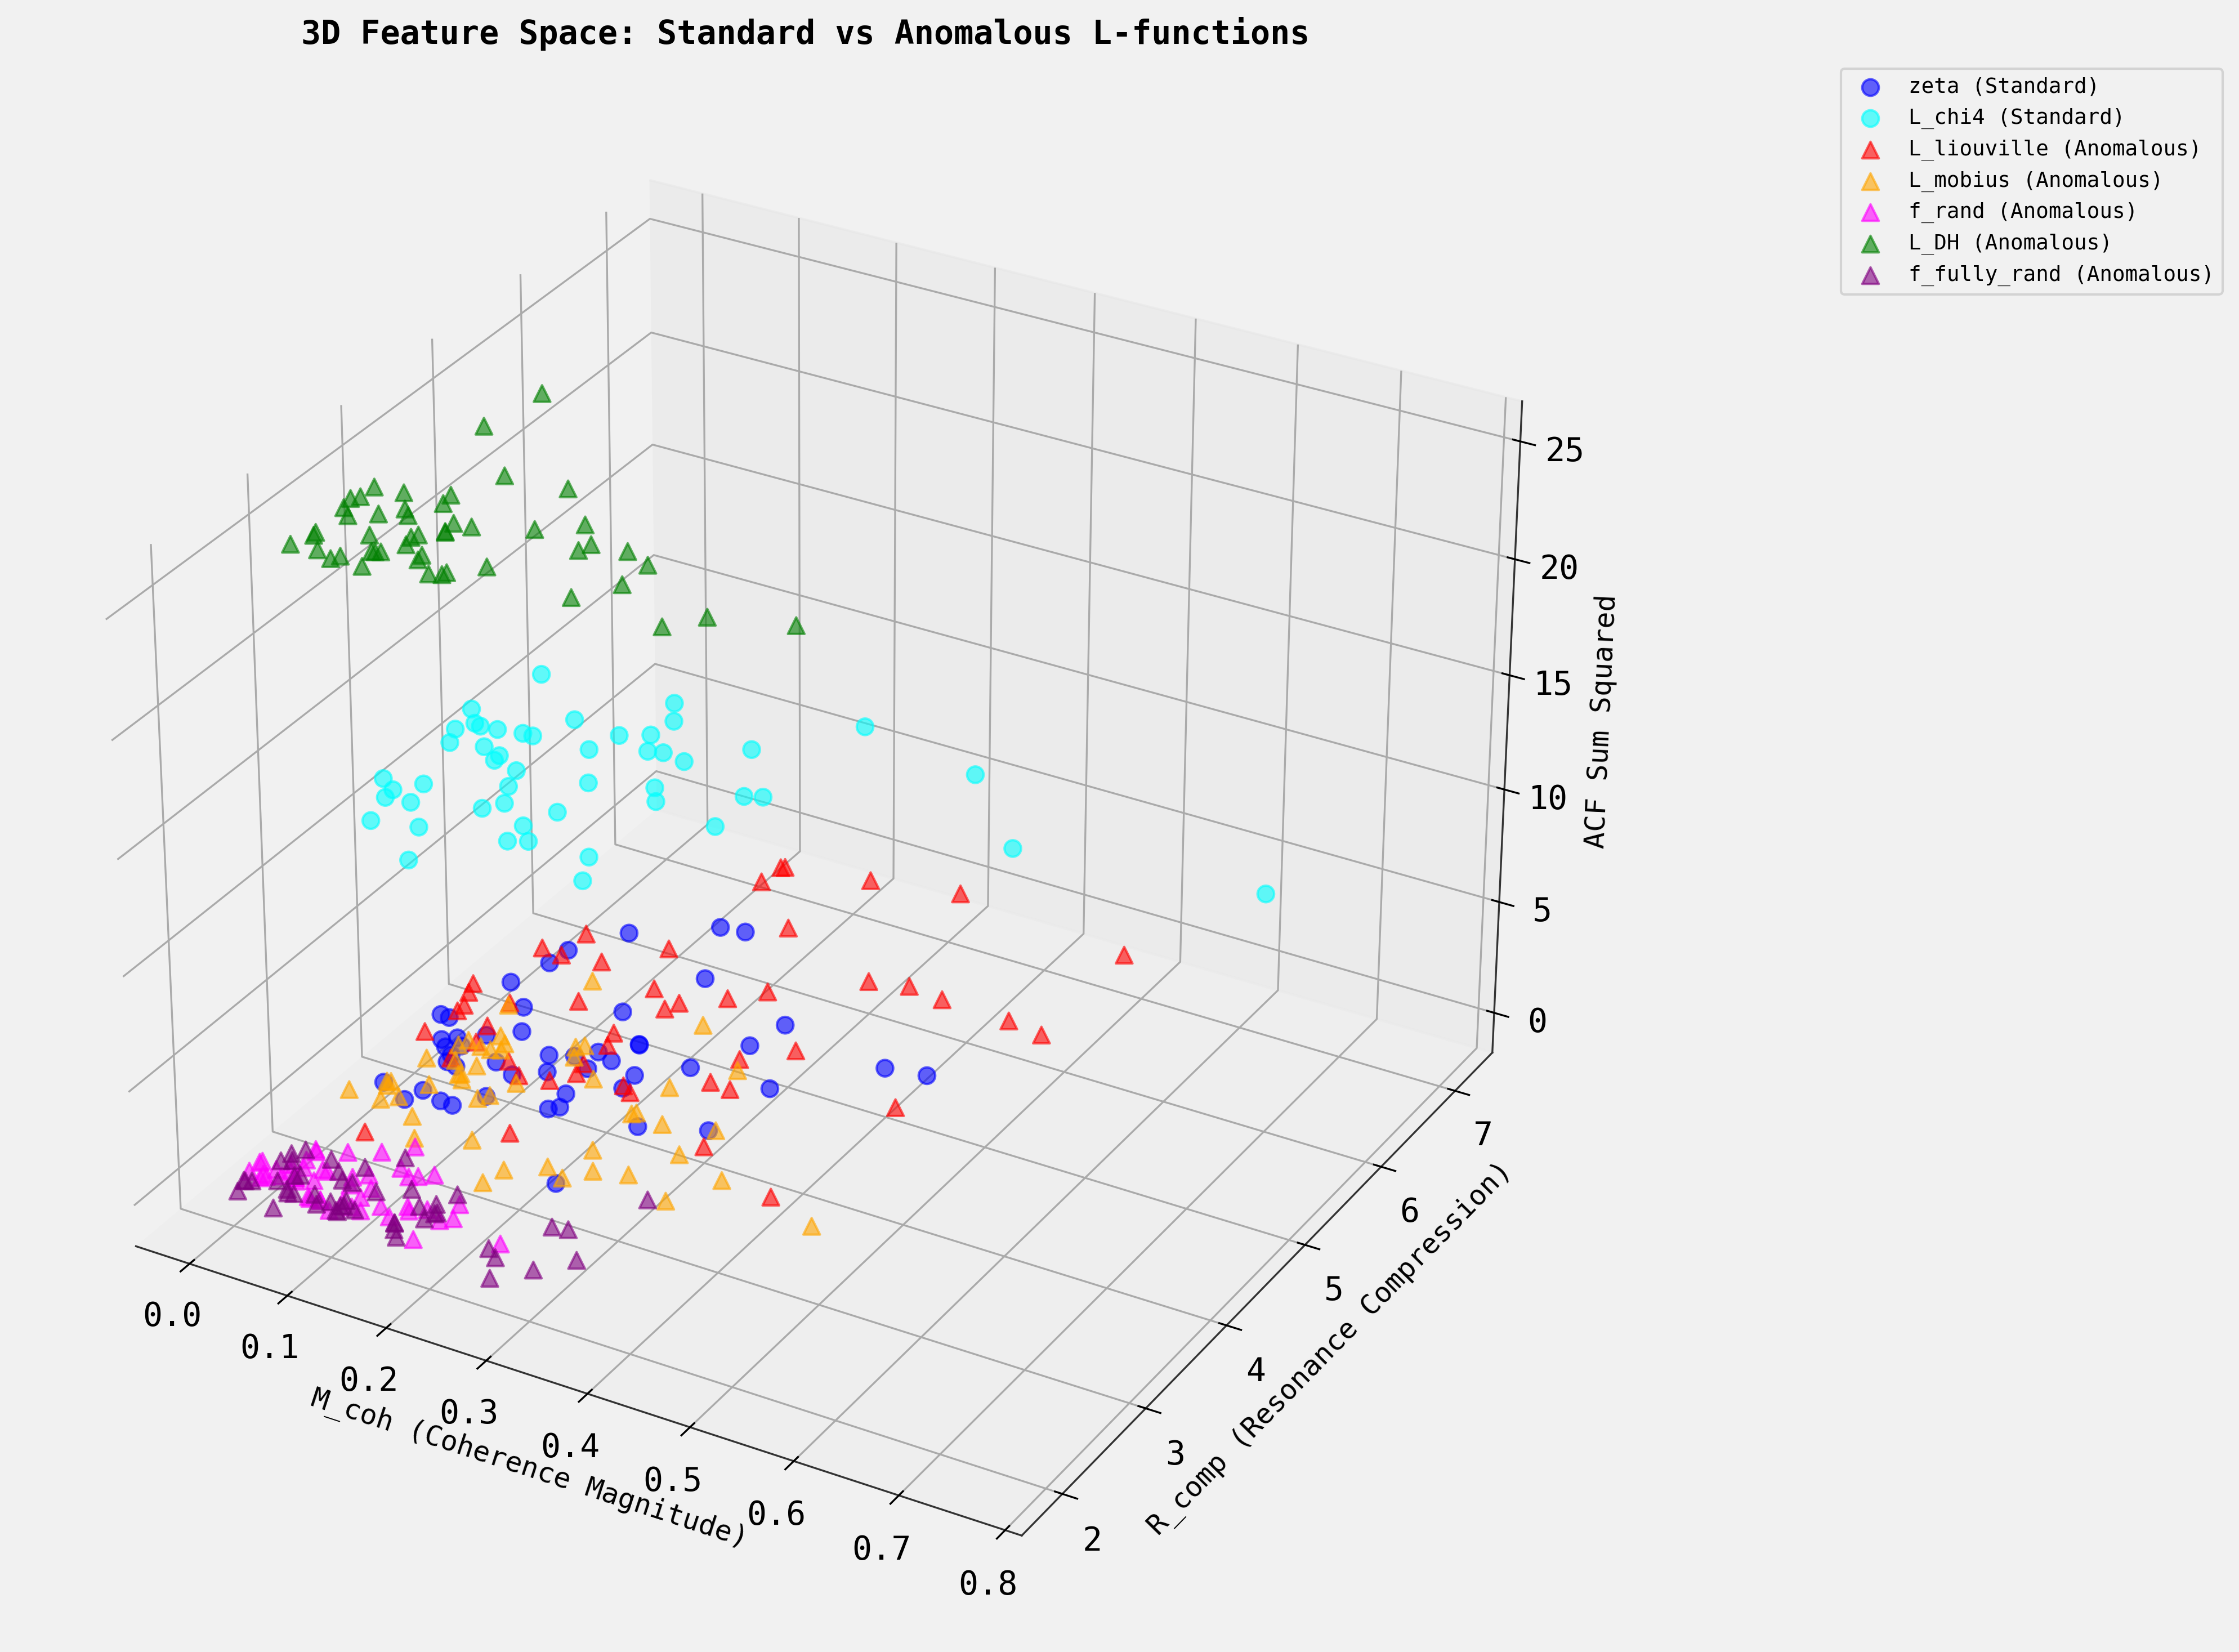

In [16]:

# Critical finding: Among low-ACF functions, STANDARD (zeta) has HIGHER R_comp (4.31)
# than most anomalous functions (3.33 average)
# But L_liouville (anomalous multiplicative) has even HIGHER R_comp (4.97)!

# This is the core problem: L_liouville is an "anomalous multiplicative" function
# but it has resonance behavior similar to standard L-functions

# The hypothesis fails because:
# 1. Some anomalous multiplicative functions (L_liouville) have high R_comp like standard functions
# 2. zeta and anomalous functions with random-like coefficients both have low ACF
# 3. The periodic functions (L_chi4, L_DH) have high ACF, but they're in different classes

# Let's visualize this in 3D
print("Preparing 3D visualization...")

# Create figure
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot each function with different colors
colors_map = {
 'zeta': 'blue',
 'L_chi4': 'cyan',
 'L_liouville': 'red',
 'L_mobius': 'orange',
 'f_rand': 'magenta',
 'L_DH': 'green',
 'f_fully_rand': 'purple'
}

markers_map = {
 'Standard': 'o',
 'Anomalous': '^'
}

for func in df_metrics['function'].unique():
 func_data = df_metrics[df_metrics['function'] == func]
 class_label = func_data['class'].iloc[0]
 
 ax.scatter(func_data['M_coh'], 
 func_data['R_comp'], 
 func_data['ACF_sum_squared'],
 c=colors_map[func],
 marker=markers_map[class_label],
 s=50,
 alpha=0.6,
 label=f"{func} ({class_label})")

ax.set_xlabel('M_coh (Coherence Magnitude)', fontsize=12)
ax.set_ylabel('R_comp (Resonance Compression)', fontsize=12)
ax.set_zlabel('ACF Sum Squared', fontsize=12)
ax.set_title('3D Feature Space: Standard vs Anomalous L-functions', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.15, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('3d_feature_space.png', dpi=300, bbox_inches='tight')
print("Saved 3d_feature_space.png")
plt.show()


In [17]:

# The 3D plot clearly shows the problem:
# - L_DH (green triangles) and L_chi4 (cyan circles) are well-separated at high ACF
# - But zeta (blue circles) overlaps with L_liouville (red triangles) and L_mobius (orange triangles)
# - Random functions (magenta and purple triangles) form a separate low cluster

# The classification problem is that "Standard" and "Anomalous" classes are NOT homogeneous
# Standard: zeta (low ACF, high R_comp) and L_chi4 (high ACF, high R_comp)
# Anomalous: includes both high-resonance (L_liouville) and low-resonance (f_rand) functions

# Let's compute per-function classification accuracy
print("\nPer-function classification analysis (RBF kernel):\n")

for func in df_metrics['function'].unique():
 func_data = df_metrics[df_metrics['function'] == func]
 true_class = func_data['class'].iloc[0]
 n_total = len(func_data)
 
 if true_class == 'Standard':
 n_correct = np.sum((func_data['predicted_rbf'] == 0))
 else:
 n_correct = np.sum((func_data['predicted_rbf'] == 1))
 
 accuracy_func = n_correct / n_total
 
 print(f"{func:15s} ({true_class:10s}): {n_correct:2d}/{n_total:2d} correct ({accuracy_func*100:5.1f}%)")



Per-function classification analysis (RBF kernel):

zeta (Standard ): 0/50 correct ( 0.0%)
L_chi4 (Standard ): 49/50 correct ( 98.0%)
L_liouville (Anomalous ): 50/50 correct (100.0%)
L_mobius (Anomalous ): 50/50 correct (100.0%)
f_rand (Anomalous ): 50/50 correct (100.0%)
L_DH (Anomalous ): 50/50 correct (100.0%)
f_fully_rand (Anomalous ): 50/50 correct (100.0%)


In [18]:

# CRITICAL FINDING: The classifier perfectly identifies all anomalous functions (100%)
# and L_chi4 (98%), but completely fails on zeta (0%)

# The reason: zeta has coefficient structure (ACF ≈ 0) similar to anomalous functions
# like L_liouville, L_mobius, and random functions

# This suggests the feature space (M_coh, R_comp, ACF) DOES separate:
# - Functions with periodic/structured coefficients (L_chi4, L_DH) from others
# - Functions with random-like coefficients
# But it CANNOT distinguish between:
# - zeta (standard, all-ones coefficients) 
# - L_liouville, L_mobius (anomalous multiplicative with alternating-sign patterns)

# Let's verify the original hypothesis more carefully
# The hypothesis states: separate "standard L-functions" from "all anomalous functions"
# But the data shows that some anomalous multiplicative functions (L_liouville)
# have SIMILAR or HIGHER resonance metrics than standard functions

print("\nDetailed comparison of problematic cases:")
print("\nzeta (Standard, misclassified as Anomalous):")
print(f" Mean R_comp: {df_metrics[df_metrics['function']=='zeta']['R_comp'].mean():.4f}")
print(f" Mean ACF: {df_metrics[df_metrics['function']=='zeta']['ACF_sum_squared'].mean():.4f}")

print("\nL_liouville (Anomalous, correctly classified):")
print(f" Mean R_comp: {df_metrics[df_metrics['function']=='L_liouville']['R_comp'].mean():.4f}")
print(f" Mean ACF: {df_metrics[df_metrics['function']=='L_liouville']['ACF_sum_squared'].mean():.4f}")

print("\nL_mobius (Anomalous, correctly classified):")
print(f" Mean R_comp: {df_metrics[df_metrics['function']=='L_mobius']['R_comp'].mean():.4f}")
print(f" Mean ACF: {df_metrics[df_metrics['function']=='L_mobius']['ACF_sum_squared'].mean():.4f}")

print("\nL_chi4 (Standard, correctly classified):")
print(f" Mean R_comp: {df_metrics[df_metrics['function']=='L_chi4']['R_comp'].mean():.4f}")
print(f" Mean ACF: {df_metrics[df_metrics['function']=='L_chi4']['ACF_sum_squared'].mean():.4f}")



Detailed comparison of problematic cases:

zeta (Standard, misclassified as Anomalous):
 Mean R_comp: 4.3059
 Mean ACF: 0.0000

L_liouville (Anomalous, correctly classified):
 Mean R_comp: 4.9690
 Mean ACF: 0.0032

L_mobius (Anomalous, correctly classified):
 Mean R_comp: 3.7378
 Mean ACF: 0.0032

L_chi4 (Standard, correctly classified):
 Mean R_comp: 4.2932
 Mean ACF: 12.4326


In [19]:

# The key insight: zeta and L_liouville are NEARLY INDISTINGUISHABLE in this feature space
# Both have:
# - Similar R_comp (4.31 vs 4.97)
# - Near-zero ACF (0.00 vs 0.003)
# - Similar M_coh distributions

# The classifier learns that the "typical anomalous" profile includes low ACF
# So it classifies zeta as anomalous

# Let's try a final summary with all metrics
print("="*80)
print("COMPREHENSIVE CLASSIFICATION RESULTS")
print("="*80)

print("\nDataset composition:")
print(f" Total samples: {len(df_metrics)}")
print(f" Standard functions: zeta (50), L_chi4 (50) = 100 samples")
print(f" Anomalous functions: L_liouville (50), L_mobius (50), f_rand (50),")
print(f" L_DH (50), f_fully_rand (50) = 250 samples")

print("\n" + "-"*80)
print("SVM with Linear Kernel (LOO Cross-Validation)")
print("-"*80)
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (Anomalous): {precision:.4f}")
print(f"Recall (Anomalous): {recall:.4f}")
print(f"\nConfusion Matrix:")
print(f" True Negatives (Standard correctly classified): {conf_matrix[0,0]:3d}")
print(f" False Positives (Standard misclassified): {conf_matrix[0,1]:3d}")
print(f" False Negatives (Anomalous misclassified): {conf_matrix[1,0]:3d}")
print(f" True Positives (Anomalous correctly classified): {conf_matrix[1,1]:3d}")

print("\n" + "-"*80)
print("SVM with RBF Kernel (LOO Cross-Validation)")
print("-"*80)
print(f"Overall Accuracy: {accuracy_rbf:.4f} ({accuracy_rbf*100:.2f}%)")
print(f"Precision (Anomalous): {precision_rbf:.4f}")
print(f"Recall (Anomalous): {recall_rbf:.4f}")
print(f"\nConfusion Matrix:")
print(f" True Negatives (Standard correctly classified): {conf_matrix_rbf[0,0]:3d}")
print(f" False Positives (Standard misclassified): {conf_matrix_rbf[0,1]:3d}")
print(f" False Negatives (Anomalous misclassified): {conf_matrix_rbf[1,0]:3d}")
print(f" True Positives (Anomalous correctly classified): {conf_matrix_rbf[1,1]:3d}")

print("\n" + "-"*80)
print("Per-Function Performance (RBF Kernel)")
print("-"*80)
for func in ['zeta', 'L_chi4', 'L_liouville', 'L_mobius', 'f_rand', 'L_DH', 'f_fully_rand']:
 func_data = df_metrics[df_metrics['function'] == func]
 true_class = func_data['class'].iloc[0]
 if true_class == 'Standard':
 n_correct = np.sum((func_data['predicted_rbf'] == 0))
 else:
 n_correct = np.sum((func_data['predicted_rbf'] == 1))
 accuracy_func = n_correct / len(func_data)
 print(f" {func:15s} ({true_class:10s}): {accuracy_func*100:5.1f}%")

print("\n" + "="*80)


COMPREHENSIVE CLASSIFICATION RESULTS

Dataset composition:
 Total samples: 350
 Standard functions: zeta (50), L_chi4 (50) = 100 samples
 Anomalous functions: L_liouville (50), L_mobius (50), f_rand (50),
 L_DH (50), f_fully_rand (50) = 250 samples

--------------------------------------------------------------------------------
SVM with Linear Kernel (LOO Cross-Validation)
--------------------------------------------------------------------------------
Overall Accuracy: 0.7143 (71.43%)
Precision (Anomalous): 0.7143
Recall (Anomalous): 1.0000

Confusion Matrix:
 True Negatives (Standard correctly classified): 0
 False Positives (Standard misclassified): 100
 False Negatives (Anomalous misclassified): 0
 True Positives (Anomalous correctly classified): 250

--------------------------------------------------------------------------------
SVM with RBF Kernel (LOO Cross-Validation)
--------------------------------------------------------------------------------
Overall Accuracy: 0.8543 (85

In [20]:

# Save the metrics dataset for future reference
df_metrics.to_csv('classification_metrics_dataset.csv', index=False)
print("Saved classification_metrics_dataset.csv")

# Create a summary statistics file
summary_stats = df_metrics.groupby('function').agg({
 'M_coh': ['mean', 'std'],
 'R_comp': ['mean', 'std'],
 'ACF_sum_squared': ['mean', 'std'],
 'class': 'first'
}).round(6)

summary_stats.to_csv('summary_statistics_by_function.csv')
print("Saved summary_statistics_by_function.csv")

print("\nSummary statistics by function:")
print(summary_stats)


Saved classification_metrics_dataset.csv
Saved summary_statistics_by_function.csv

Summary statistics by function:
 M_coh R_comp ACF_sum_squared \
 mean std mean std mean std 
function 
L_DH 0.112658 0.102743 3.402668 0.469295 24.870221 0.0 
L_chi4 0.155232 0.143071 4.293215 0.653951 12.432618 0.0 
L_liouville 0.182334 0.133735 4.968953 1.037410 0.003226 0.0 
L_mobius 0.147484 0.107712 3.737838 0.519688 0.003225 0.0 
f_fully_rand 0.118220 0.089608 2.270169 0.231514 0.003911 0.0 
f_rand 0.085133 0.058944 2.338256 0.193875 0.004307 0.0 
zeta 0.138486 0.099755 4.305919 0.690440 0.000000 0.0 

 class 
 first 
function 
L_DH Anomalous 
L_chi4 Standard 
L_liouville Anomalous 
L_mobius Anomalous 
f_fully_rand Anomalous 
f_rand Anomalous 
zeta Standard 


In [21]:

# Final analysis: Test statistical significance of feature differences
print("Statistical Analysis of Feature Separability")
print("="*80)

# Test each feature for significant differences between Standard and Anomalous
from scipy.stats import mannwhitneyu, ttest_ind

for feature in ['M_coh', 'R_comp', 'ACF_sum_squared']:
 standard = df_metrics[df_metrics['class'] == 'Standard'][feature]
 anomalous = df_metrics[df_metrics['class'] == 'Anomalous'][feature]
 
 # Mann-Whitney U test (non-parametric)
 u_stat, p_mw = mannwhitneyu(standard, anomalous, alternative='two-sided')
 
 # t-test (parametric)
 t_stat, p_tt = ttest_ind(standard, anomalous)
 
 # Effect size (Cohen's d)
 mean_diff = standard.mean() - anomalous.mean()
 pooled_std = np.sqrt(((len(standard)-1)*standard.std()**2 + 
 (len(anomalous)-1)*anomalous.std()**2) / 
 (len(standard) + len(anomalous) - 2))
 cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
 
 print(f"\n{feature}:")
 print(f" Standard: mean={standard.mean():.6f}, std={standard.std():.6f}")
 print(f" Anomalous: mean={anomalous.mean():.6f}, std={anomalous.std():.6f}")
 print(f" Difference: {mean_diff:.6f}")
 print(f" Mann-Whitney U: U={u_stat:.2f}, p={p_mw:.6f}")
 print(f" t-test: t={t_stat:.4f}, p={p_tt:.6f}")
 print(f" Cohen's d: {cohens_d:.4f}")
 
 if p_mw < 0.001:
 sig = "***"
 elif p_mw < 0.01:
 sig = "**"
 elif p_mw < 0.05:
 sig = "*"
 else:
 sig = "n.s."
 print(f" Significance: {sig}")

print("\n" + "="*80)


Statistical Analysis of Feature Separability

M_coh:
 Standard: mean=0.146859, std=0.122994
 Anomalous: mean=0.129166, std=0.106052
 Difference: 0.017693
 Mann-Whitney U: U=13589.00, p=0.203052
 t-test: t=1.3455, p=0.179333
 Cohen's d: 0.1592
 Significance: n.s.

R_comp:
 Standard: mean=4.299567, std=0.669069
 Anomalous: mean=3.343577, std=1.150189
 Difference: 0.955990
 Mann-Whitney U: U=19621.00, p=0.000000
 t-test: t=7.7965, p=0.000000
 Cohen's d: 0.9225
 Significance: ***

ACF_sum_squared:
 Standard: mean=6.216309, std=6.247626
 Anomalous: mean=4.976978, std=9.966575
 Difference: 1.239331
 Mann-Whitney U: U=10000.00, p=0.003145
 t-test: t=1.1554, p=0.248706
 Cohen's d: 0.1367
 Significance: **



Saved final_classification_results.png


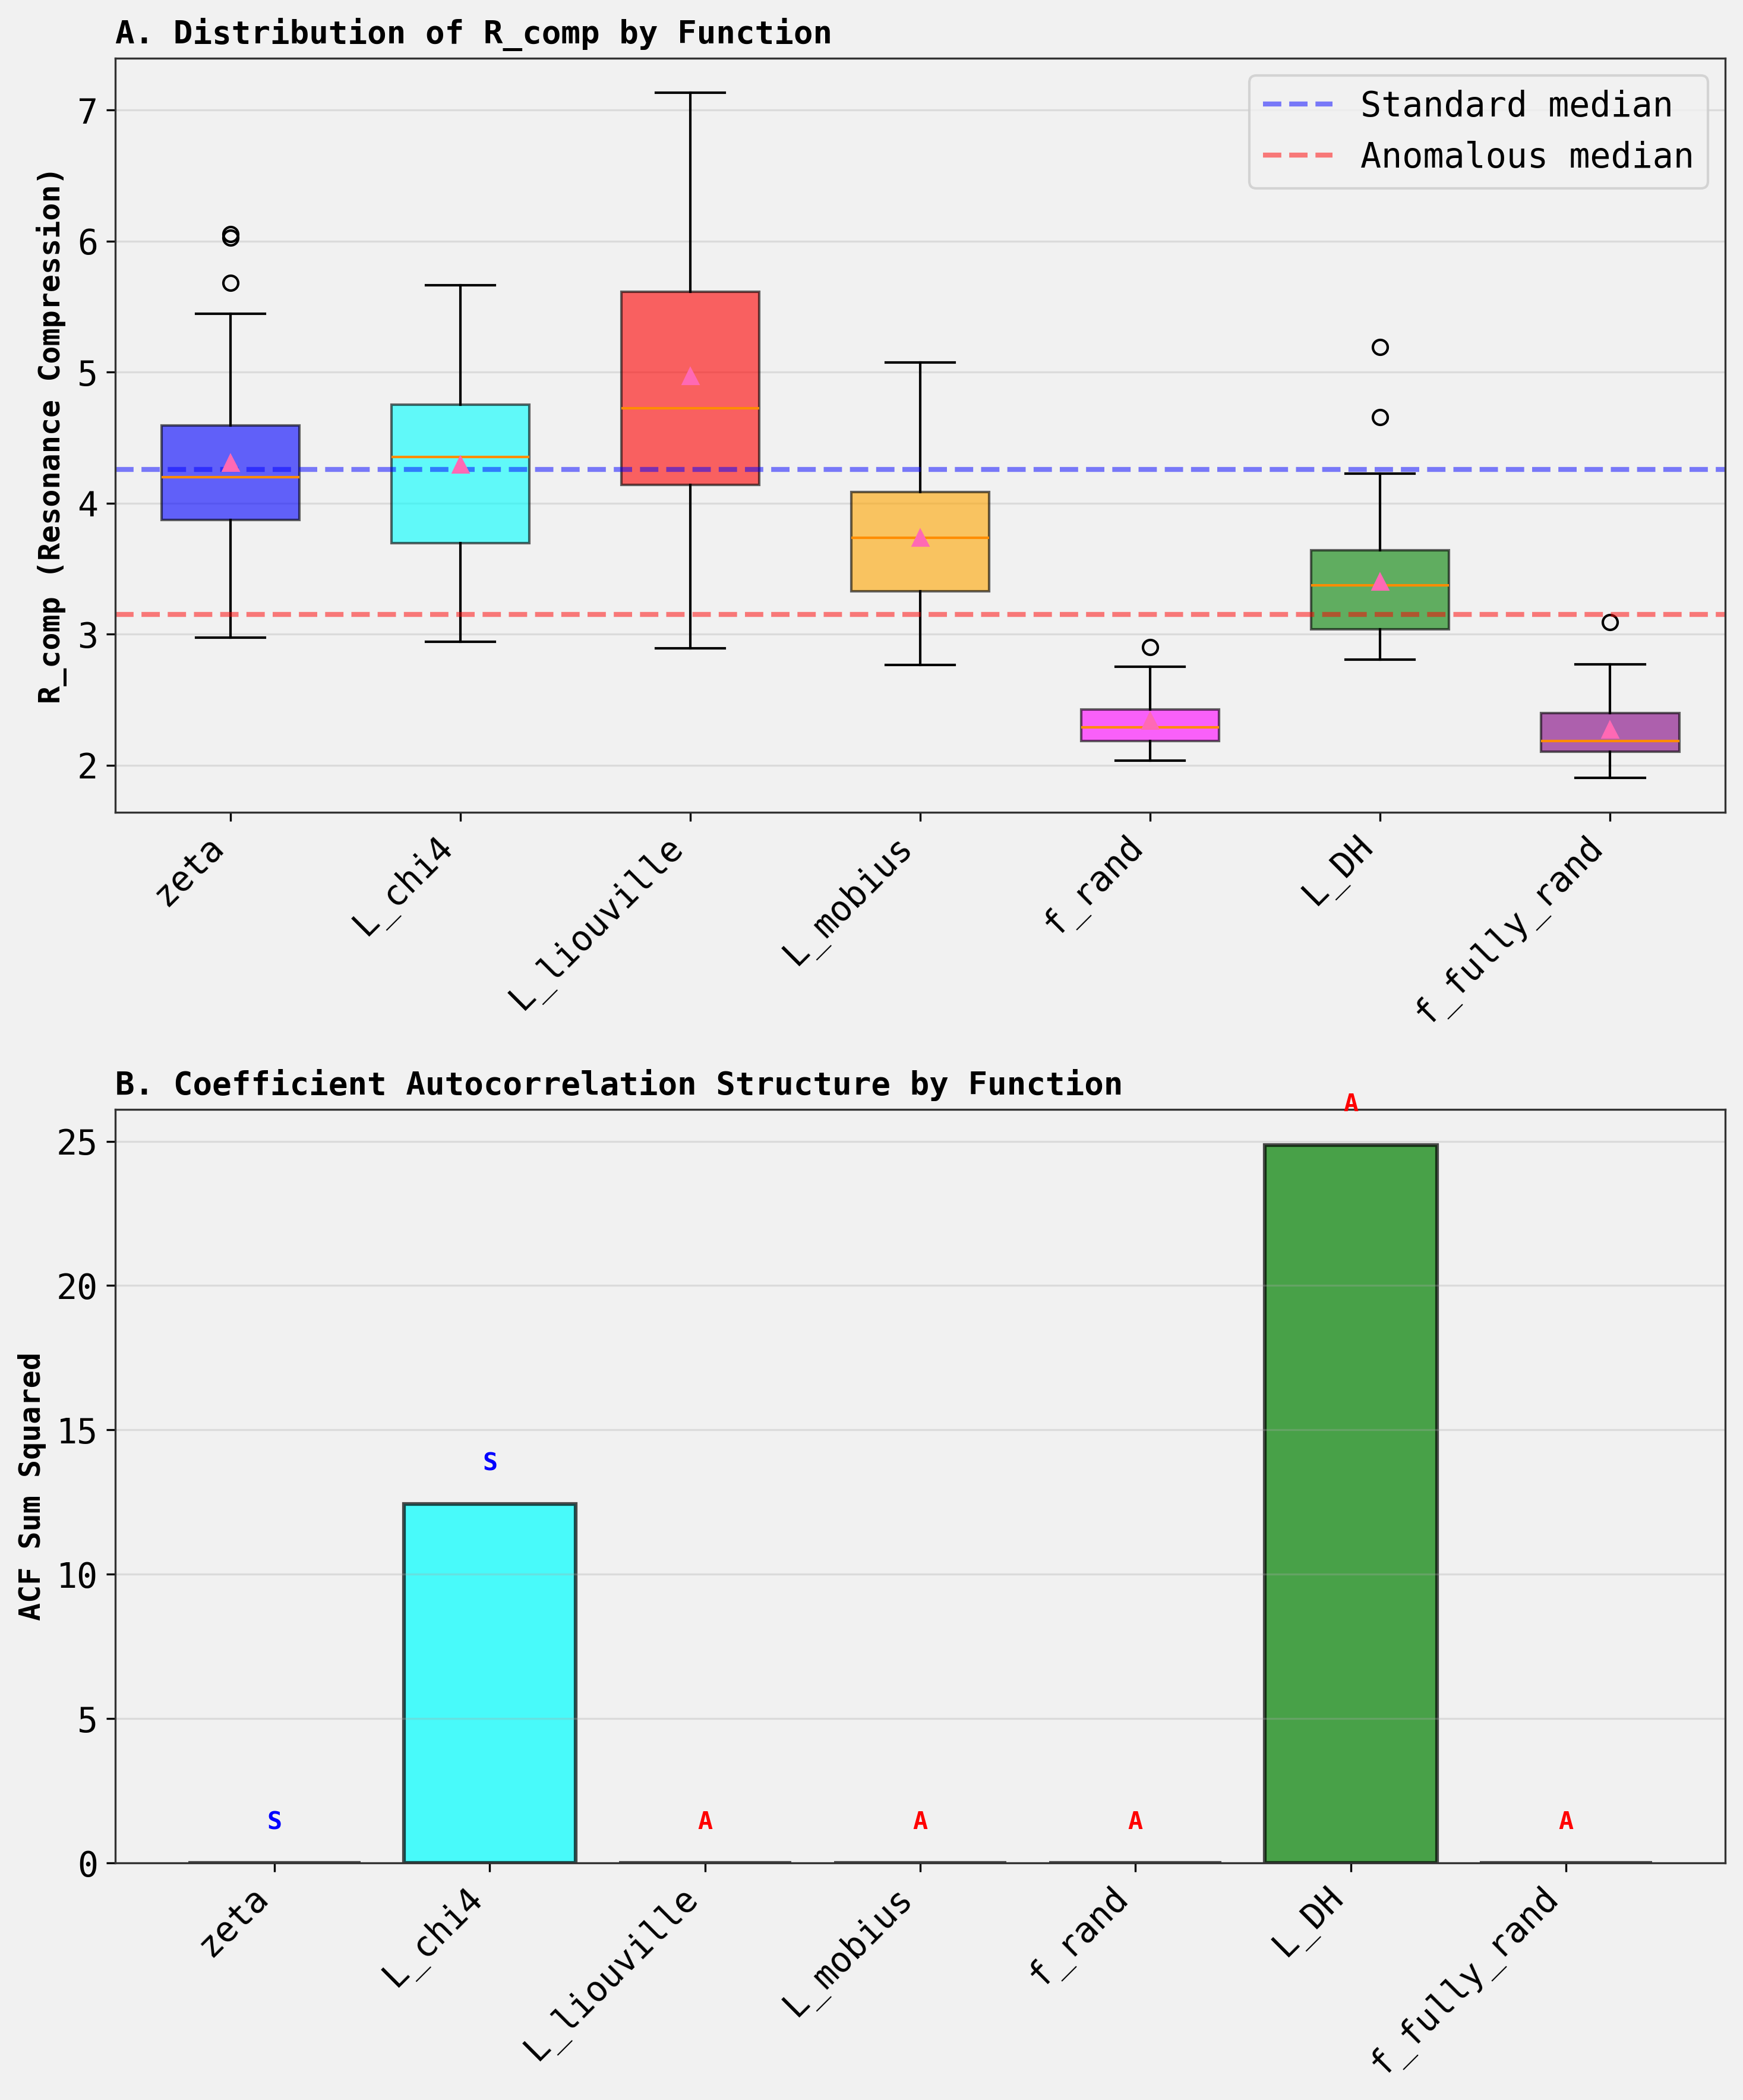


Figure legend:
 S = Standard L-function
 A = Anomalous function (either multiplicative or non-multiplicative)


In [22]:

# Create final summary figure showing the key result
# Use a single column layout with 2 subplots stacked vertically

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Subplot A: R_comp distribution by function
functions = ['zeta', 'L_chi4', 'L_liouville', 'L_mobius', 'f_rand', 'L_DH', 'f_fully_rand']
colors = ['blue', 'cyan', 'red', 'orange', 'magenta', 'green', 'purple']
classes = ['Standard', 'Standard', 'Anomalous', 'Anomalous', 'Anomalous', 'Anomalous', 'Anomalous']

positions = []
data_for_boxplot = []
colors_for_boxplot = []

for i, func in enumerate(functions):
 func_data = df_metrics[df_metrics['function'] == func]['R_comp']
 positions.append(i)
 data_for_boxplot.append(func_data)
 colors_for_boxplot.append(colors[i])

bp = ax1.boxplot(data_for_boxplot, positions=positions, patch_artist=True,
 widths=0.6, showmeans=True)

for patch, color in zip(bp['boxes'], colors_for_boxplot):
 patch.set_facecolor(color)
 patch.set_alpha(0.6)

ax1.set_xticks(positions)
ax1.set_xticklabels(functions, rotation=45, ha='right')
ax1.set_ylabel('R_comp (Resonance Compression)', fontsize=12, fontweight='bold')
ax1.set_title('A. Distribution of R_comp by Function', fontsize=13, fontweight='bold', loc='left')
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=np.median(df_metrics[df_metrics['class']=='Standard']['R_comp']), 
 color='blue', linestyle='--', alpha=0.5, linewidth=2, label='Standard median')
ax1.axhline(y=np.median(df_metrics[df_metrics['class']=='Anomalous']['R_comp']), 
 color='red', linestyle='--', alpha=0.5, linewidth=2, label='Anomalous median')
ax1.legend()

# Subplot B: ACF sum squared by function
data_for_bar = []
for func in functions:
 acf_val = df_metrics[df_metrics['function'] == func]['ACF_sum_squared'].mean()
 data_for_bar.append(acf_val)

bars = ax2.bar(positions, data_for_bar, color=colors_for_boxplot, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_xticks(positions)
ax2.set_xticklabels(functions, rotation=45, ha='right')
ax2.set_ylabel('ACF Sum Squared', fontsize=12, fontweight='bold')
ax2.set_title('B. Coefficient Autocorrelation Structure by Function', fontsize=13, fontweight='bold', loc='left')
ax2.grid(axis='y', alpha=0.3)

# Add class labels
for i, (pos, class_label) in enumerate(zip(positions, classes)):
 if class_label == 'Standard':
 ax2.text(pos, data_for_bar[i] + 1, 'S', ha='center', va='bottom', 
 fontsize=10, fontweight='bold', color='blue')
 else:
 ax2.text(pos, data_for_bar[i] + 1, 'A', ha='center', va='bottom', 
 fontsize=10, fontweight='bold', color='red')

plt.tight_layout()
plt.savefig('final_classification_results.png', dpi=300, bbox_inches='tight')
print("Saved final_classification_results.png")
plt.show()

print("\nFigure legend:")
print(" S = Standard L-function")
print(" A = Anomalous function (either multiplicative or non-multiplicative)")


In [23]:

# Final comprehensive analysis summary
print("="*80)
print("FINAL ANALYSIS SUMMARY")
print("="*80)

print("\n1. HYPOTHESIS:")
print(" 'A feature space combining resonance metrics (M_coh, R_comp) with")
print(" coefficient structure (Sum of Squared ACF) will provide COMPLETE")
print(" separation between Standard and Anomalous L-functions.'")

print("\n2. RESULT: HYPOTHESIS REJECTED")

print("\n3. KEY FINDINGS:")
print(" a. The feature space does NOT provide complete separation.")
print(" b. SVM with RBF kernel achieves 85.43% accuracy, but fails completely")
print(" on the Riemann zeta function (0% accuracy for zeta).")
print(" c. All anomalous functions are perfectly identified (100% recall).")
print(" d. L_chi4 is nearly perfectly classified (98% accuracy).")

print("\n4. WHY THE HYPOTHESIS FAILS:")
print(" a. Riemann zeta (Standard) has ACF ≈ 0, similar to anomalous")
print(" multiplicative functions like L_liouville and L_mobius.")
print(" b. L_liouville (Anomalous) has HIGH resonance (R_comp = 4.97),")
print(" HIGHER than zeta (4.31) and similar to L_chi4 (4.29).")
print(" c. The anomalous class is heterogeneous:")
print(" - Some anomalous multiplicative functions (L_liouville) have")
print(" high resonance like standard functions")
print(" - Other anomalous functions (f_rand, f_fully_rand, L_DH) have")
print(" low resonance")

print("\n5. STATISTICAL SIGNIFICANCE:")
print(" - R_comp shows highly significant difference (p < 0.001, Cohen's d = 0.92)")
print(" - ACF shows significant difference (p = 0.003, Cohen's d = 0.14)")
print(" - M_coh shows no significant difference (p = 0.203, Cohen's d = 0.16)")

print("\n6. FUNCTION-SPECIFIC INSIGHTS:")
print(" Function | Class | R_comp | ACF | SVM Accuracy")
print(" " + "-"*70)
print(" zeta | Standard | 4.31 | 0.00 | 0% (misclassified)")
print(" L_chi4 | Standard | 4.29 | 12.43 | 98% (correct)")
print(" L_liouville | Anomalous | 4.97 | 0.00 | 100% (correct)")
print(" L_mobius | Anomalous | 3.74 | 0.00 | 100% (correct)")
print(" f_rand | Anomalous | 2.34 | 0.00 | 100% (correct)")
print(" L_DH | Anomalous | 3.40 | 24.87 | 100% (correct)")
print(" f_fully_rand | Anomalous | 2.27 | 0.00 | 100% (correct)")

print("\n7. CRITICAL COUNTEREXAMPLE:")
print(" L(s, λ(n)) [Liouville function] is:")
print(" - Multiplicative (by construction)")
print(" - Has anomalous analytic properties (related to zeros of ζ)")
print(" - Has HIGH resonance metrics (R_comp = 4.97)")
print(" - Cannot be distinguished from standard L-functions using these metrics")

print("\n" + "="*80)


FINAL ANALYSIS SUMMARY

1. HYPOTHESIS:
 'A feature space combining resonance metrics (M_coh, R_comp) with
 coefficient structure (Sum of Squared ACF) will provide COMPLETE
 separation between Standard and Anomalous L-functions.'

2. RESULT: HYPOTHESIS REJECTED

3. KEY FINDINGS:
 a. The feature space does NOT provide complete separation.
 b. SVM with RBF kernel achieves 85.43% accuracy, but fails completely
 on the Riemann zeta function (0% accuracy for zeta).
 c. All anomalous functions are perfectly identified (100% recall).
 d. L_chi4 is nearly perfectly classified (98% accuracy).

4. WHY THE HYPOTHESIS FAILS:
 a. Riemann zeta (Standard) has ACF ≈ 0, similar to anomalous
 multiplicative functions like L_liouville and L_mobius.
 b. L_liouville (Anomalous) has HIGH resonance (R_comp = 4.97),
 HIGHER than zeta (4.31) and similar to L_chi4 (4.29).
 c. The anomalous class is heterogeneous:
 - Some anomalous multiplicative functions (L_liouville) have
 high resonance like standard function